## **Setup**

### **Import Libraries**

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

### **Load The Dataset**

In [89]:
hist_2020 = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer C_Agricultural Expression/02_ANOMALY & STRESS DETECTION/data/historical_2020.csv")
hist_2021 = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer C_Agricultural Expression/02_ANOMALY & STRESS DETECTION/data/historical_2021.csv")
hist_2022 = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer C_Agricultural Expression/02_ANOMALY & STRESS DETECTION/data/historical_2022.csv")
hist_2023 = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer C_Agricultural Expression/02_ANOMALY & STRESS DETECTION/data/historical_2023.csv")

target_2024 = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer C_Agricultural Expression/02_ANOMALY & STRESS DETECTION/data/target_2024.csv")


### **Convert Dates**

In [90]:
for df in [hist_2020, hist_2021, hist_2022, hist_2023, target_2024]:
    df["Date"] = pd.to_datetime(df["Date"])

### **Sort Date**

In [91]:
for df in [hist_2020, hist_2021, hist_2022, hist_2023, target_2024]:
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

### **Ploting the Historical NDVI Curve and target NDVI**

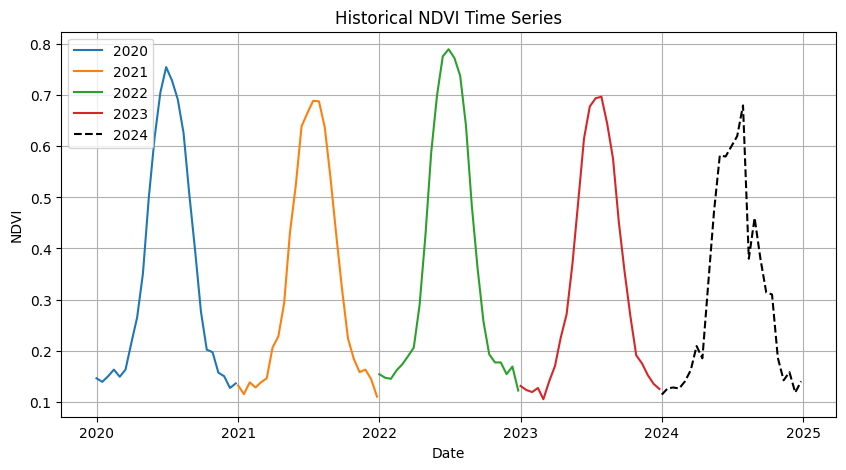

In [92]:
plt.figure(figsize=(10,5))

plt.plot(hist_2020["Date"], hist_2020["NDVI"], label="2020")
plt.plot(hist_2021["Date"], hist_2021["NDVI"], label="2021")
plt.plot(hist_2022["Date"], hist_2022["NDVI"], label="2022")
plt.plot(hist_2023["Date"], hist_2023["NDVI"], label="2023")

plt.plot(target_2024["Date"], target_2024["NDVI"], label="2024", linestyle="--", color="black")

plt.title("Historical NDVI Time Series")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)

plt.show()

### **Build the Multi-Year Baseline**

In [93]:
baseline = pd.DataFrame()

baseline["Date"] = hist_2020["Date"].dt.strftime("%m-%d")

baseline["Baseline_NDVI"] = (
    hist_2020["NDVI"] +
    hist_2021["NDVI"] +
    hist_2022["NDVI"] +
    hist_2023["NDVI"]
) / 4

baseline.head()

,Date,Baseline_NDVI
0,01-01,0.14075
1,01-16,0.13100
2,01-31,0.13800
3,02-15,0.14500
4,03-01,0.14125


### **Ploting The Baseline**

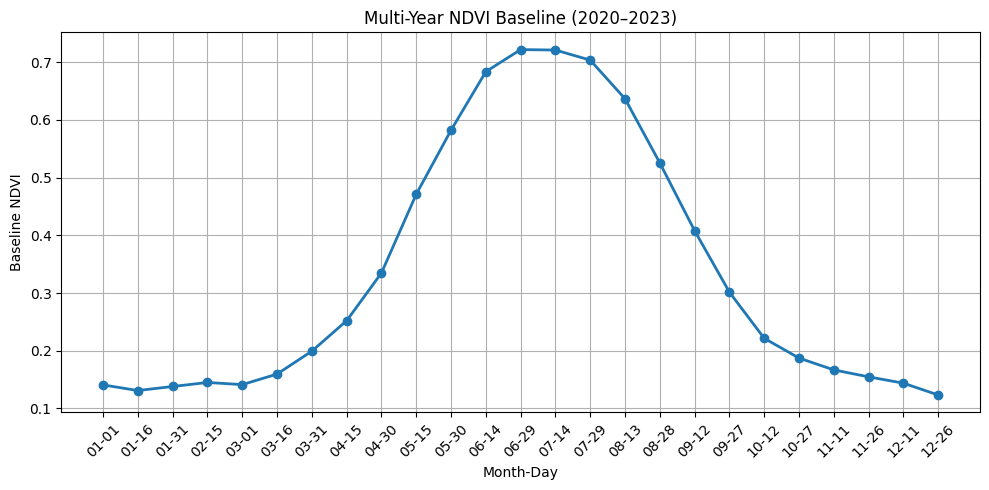

In [94]:
plt.figure(figsize=(10,5))

plt.plot(
    baseline["Date"],
    baseline["Baseline_NDVI"],
    marker="o",
    linewidth=2
)

plt.title("Multi-Year NDVI Baseline (2020–2023)")
plt.xlabel("Month-Day")
plt.ylabel("Baseline NDVI")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

## **Compute NDVI Anomalies**

### **Prepare the Target Dataset**

In [95]:
target_2024["Month_Day"] = target_2024["Date"].dt.strftime("%m-%d")

### **Prepare the Baseline**

In [96]:
baseline.rename(columns={"Date": "Month_Day"}, inplace=True)

### **Merge the Baseline with the Target Year**

In [97]:
target_2024 = target_2024.merge(
    baseline,
    on="Month_Day",
    how="left"
)
target_2024.head()

,Date,NDVI,Month_Day,Baseline_NDVI
0,2024-01-01,0.114,01-01,0.14075
1,2024-01-16,0.126,01-16,0.13100
2,2024-01-31,0.128,01-31,0.13800
3,2024-02-15,0.126,02-15,0.14500
4,2024-03-01,0.140,03-01,0.14125


### **Plot Observed vs Baseline**

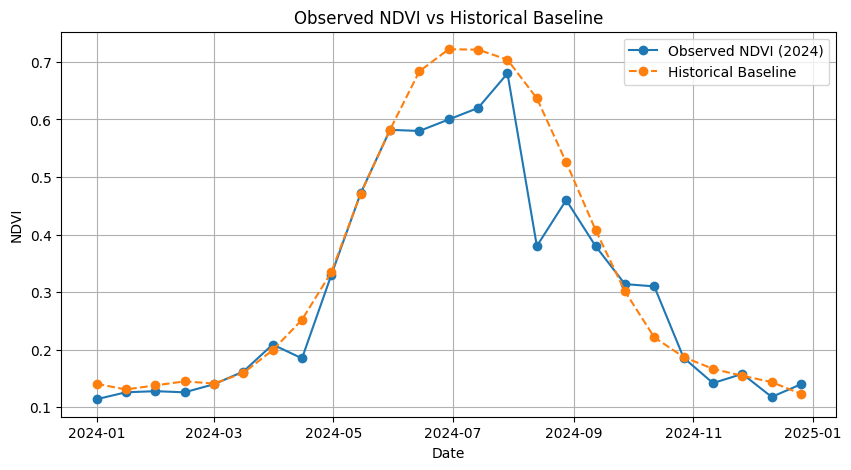

In [98]:
plt.figure(figsize=(10, 5))

plt.plot(
    target_2024["Date"],
    target_2024["NDVI"],
    marker="o",
    label="Observed NDVI (2024)"
)

plt.plot(
    target_2024["Date"],
    target_2024["Baseline_NDVI"],
    linestyle="--",
    marker="o",
    label="Historical Baseline"
)

plt.title("Observed NDVI vs Historical Baseline")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)

plt.show()

### **Calculate the Anomaly**

In [99]:
target_2024["Anomaly"] = (
    target_2024["NDVI"] -
    target_2024["Baseline_NDVI"]
)

target_2024.head()

,Date,NDVI,Month_Day,Baseline_NDVI,Anomaly
0,2024-01-01,0.114,01-01,0.14075,-0.02675
1,2024-01-16,0.126,01-16,0.13100,-0.00500
2,2024-01-31,0.128,01-31,0.13800,-0.01000
3,2024-02-15,0.126,02-15,0.14500,-0.01900
4,2024-03-01,0.140,03-01,0.14125,-0.00125


### **Plot the Anomaly Time Series**

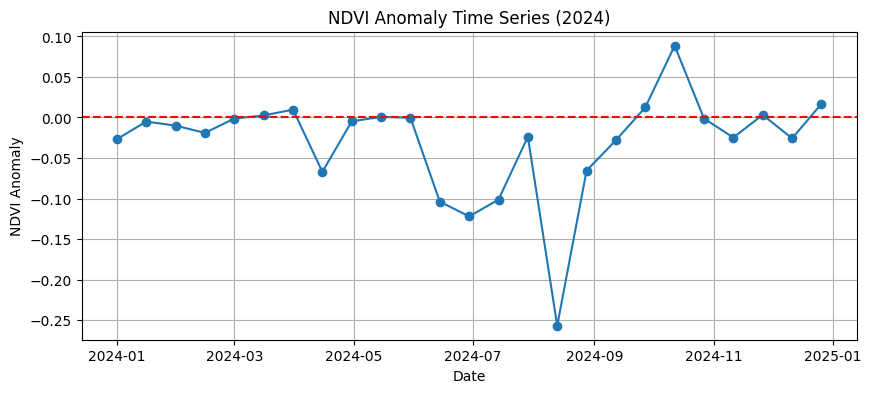

In [100]:
plt.figure(figsize=(10, 4))

plt.plot(
    target_2024["Date"],
    target_2024["Anomaly"],
    marker="o"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("NDVI Anomaly Time Series (2024)")
plt.xlabel("Date")
plt.ylabel("NDVI Anomaly")
plt.grid(True)

plt.show()

## **Classify the Anomalies**

### **Define a Simple Threshold**

This means:

* Anomaly > 0.03 → Positive
* Anomaly < -0.03 → Negative
* Otherwise → Near-zero

In [101]:
threshold = 0.03

### **Create a Classification Function**

In [102]:
def classify_anomaly(value):
    if value > threshold:
        return "Positive"
    elif value < -threshold:
        return "Negative"
    else:
        return "Near-zero"

### **Apply the Classification**

In [103]:
target_2024["Type"] = target_2024["Anomaly"].apply(classify_anomaly)

target_2024.head()

,Date,NDVI,Month_Day,Baseline_NDVI,Anomaly,Type
0,2024-01-01,0.114,01-01,0.14075,-0.02675,Near-zero
1,2024-01-16,0.126,01-16,0.13100,-0.00500,Near-zero
2,2024-01-31,0.128,01-31,0.13800,-0.01000,Near-zero
3,2024-02-15,0.126,02-15,0.14500,-0.01900,Near-zero
4,2024-03-01,0.140,03-01,0.14125,-0.00125,Near-zero


### **Count the Classes**

In [104]:
target_2024["Type"].value_counts()

,count
Type,
Near-zero,18
Negative,6
Positive,1


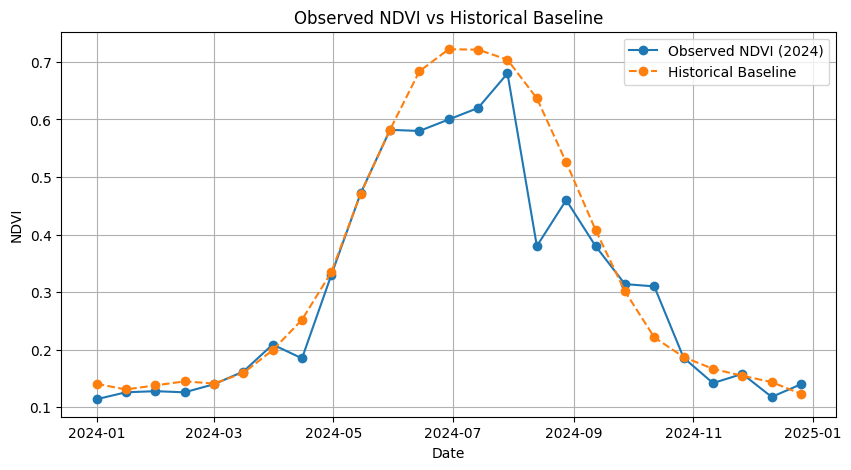

In [105]:
plt.figure(figsize=(10, 5))

plt.plot(
    target_2024["Date"],
    target_2024["NDVI"],
    marker="o",
    label="Observed NDVI (2024)"
)

plt.plot(
    target_2024["Date"],
    target_2024["Baseline_NDVI"],
    linestyle="--",
    marker="o",
    label="Historical Baseline"
)

plt.title("Observed NDVI vs Historical Baseline")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)

plt.show()

### **Identify Patterns**
After inspecting the anomaly curve:

- **Single-date anomaly**
  - Example: Around 2024-04, NDVI briefly drops below the baseline and recovers in the next observation.

- **Persistent anomaly**
  - Example: June to August shows several consecutive negative anomalies.

- **Abrupt anomaly**
  - Example: A sharp NDVI decrease occurs between 2024-07-29 and 2024-08-13.

## **Describe Each Important Anomaly**

### **Create a Description Table**

In [106]:
anomaly_description = pd.DataFrame({
    "Date": [],
    "Direction": [],
    "Magnitude": [],
    "Duration": [],
    "Timing": []
})

### **Direction Classification**

In [107]:
def direction_class(value):
    if value > 0:
        return "Positive"
    elif value < 0:
        return "Negative"

target_2024["Direction"] = target_2024["Anomaly"].apply(direction_class)

### **Magnitude Classification**

In [108]:
def magnitude_class(value):
    if abs(value) < 0.03:
        return "Small"
    elif abs(value) < 0.08:
        return "Moderate"
    else:
        return "Large"


target_2024["Magnitude"] = target_2024["Anomaly"].apply(
    magnitude_class
)

### **Duration Classification**

Find the important anamoly and then find out the duration manually, this will be more easy.

### **Timing Classification**

In [109]:
def season_period(date):
    month = date.month

    if month <= 3:
        return "Early season"
    elif month <= 6:
        return "Vegetative growth"
    elif month <= 8:
        return "Peak season"
    elif month <= 10:
        return "Late season"
    else:
        return "Post-season"


target_2024["Timing"] = target_2024["Date"].apply(
    season_period
)

In [87]:
target_2024.head()

,Date,NDVI,Month_Day,Baseline_NDVI,Anomaly,Type,Direction,Magnitude,Timing,Is_Anomaly,Anomaly_Group
0,2024-01-01,0.114,01-01,0.14075,-0.02675,Near-zero,Negative,Small,Early season,False,1
1,2024-01-16,0.126,01-16,0.13100,-0.00500,Near-zero,Negative,Small,Early season,False,1
2,2024-01-31,0.128,01-31,0.13800,-0.01000,Near-zero,Negative,Small,Early season,False,1
3,2024-02-15,0.126,02-15,0.14500,-0.01900,Near-zero,Negative,Small,Early season,False,1
4,2024-03-01,0.140,03-01,0.14125,-0.00125,Near-zero,Negative,Small,Early season,False,1


Now you have to find the change point, and make some hypothesis, later validate them with the evidance.

But as this is a curated dataset, I don't have any evidance. So, this is just leaning how to practically calcualte the anamoly.